In [3]:
import os
import json
import matplotlib.pyplot as plt
import tiktoken
import numpy as np
import cv2

import torch
import torch.nn as nn
import torchvision.models as models
from torchvision import transforms
from torch.utils.data import Dataset, DataLoader
from torch.utils.tensorboard import SummaryWriter

from PIL import Image
from tqdm import tqdm

device = 'cuda' if torch.cuda.is_available() else 'cpu'
print(f"Using Device : {device}\nDevice Name  : {torch.cuda.get_device_name(0)}")


Using Device : cuda
Device Name  : NVIDIA GeForce GTX 1650


In [4]:
class Config:
    d_model = 512
    context_length = 30 # found by data/coco2017/annotations/data_analysis.ipynb
    dropout = 0.1
    
    batch_size = 32
    num_epochs = 10
    learning_rate = 0.001

    model_save_path = "models/"
    model_name = f"Caption_RNN_D{d_model}C{context_length}D{dropout}"

config = Config()
writer = SummaryWriter(log_dir="runs/caption_RNN_Model")

In [5]:
class CocoDataset(Dataset):
    def __init__(self, image_dir, annotation_file, context_length, transform=None, tokenizer=None):
        self.image_dir = image_dir
        self.transform = transform
        self.tokenizer = tokenizer

        with open(annotation_file, 'r') as f:
            data = json.load(f)

        # build (image, caption) pairs
        self.samples = []
        self.max_len = context_length # found by data/coco2017/annotations/data_analysis.ipynb
        for file_name, captions in data.items():
            for caption in captions:
                caption = self.tokenizer.encode(caption)
                if len(caption)>self.max_len-2:
                    caption = caption[:self.max_len-2]
                caption = [50257] + caption + [50258] # <Start> caption <END>
                if len(caption)<self.max_len:
                    total_pads_to_add = self.max_len - (len(caption))
                    caption = caption + [50259] * total_pads_to_add
                self.samples.append((file_name, caption))

    def __len__(self):
        return len(self.samples)

    def __getitem__(self, idx):
        file_name, caption = self.samples[idx]

        img_path = os.path.join(self.image_dir, file_name)
        image = Image.open(img_path).convert("RGB")

        if self.transform:
            image = self.transform(image)

        return image, torch.tensor(caption, dtype=torch.long)


In [6]:
train_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.RandomRotation(10),
    transforms.RandomResizedCrop(224, scale=(0.8, 1.0)),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])

val_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])


In [7]:
tokenizer = tiktoken.get_encoding("gpt2")

special_tokens = {
    "<START>": 50257,
    "<END>": 50258,
    "<PAD>": 50259,
}

tokenizer = tiktoken.Encoding(
    name="gpt2_extended",
    pat_str=tokenizer._pat_str,
    mergeable_ranks=tokenizer._mergeable_ranks,
    special_tokens=special_tokens
)


In [8]:
train_dataset = CocoDataset(
    image_dir="data/coco2017/train2017",
    annotation_file="data/coco2017/annotations/train_captions_custom.json",
    context_length=config.context_length,
    transform=train_transform,
    tokenizer=tokenizer
)

val_dataset = CocoDataset(
    image_dir="data/coco2017/val2017",
    annotation_file="data/coco2017/annotations/val_captions_custom.json",
    context_length=config.context_length,
    transform=val_transform,
    tokenizer=tokenizer
)

train_dataloader = DataLoader(train_dataset, batch_size=config.batch_size, shuffle=True)
val_dataloader = DataLoader(val_dataset, batch_size=config.batch_size, shuffle=False)


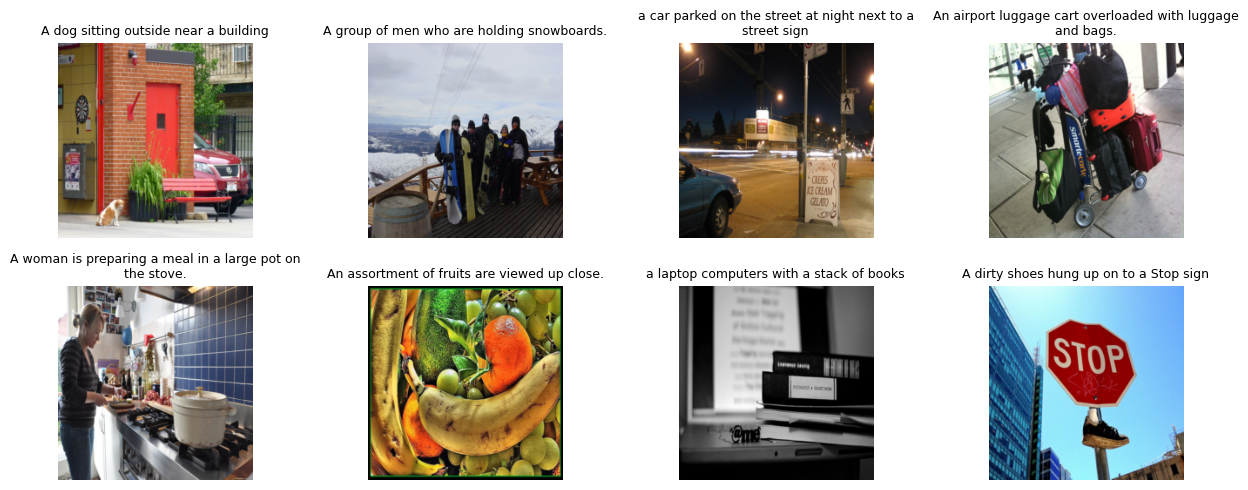

In [9]:
import random
import textwrap

# Random sample visualization (raw captions from dataset; tensor view matches val preprocessing)
indices = random.sample(range(len(train_dataset)), k=min(8, len(train_dataset)))
fig, axes = plt.subplots(2, 4, figsize=(13, 5))
axes = axes.flatten()
mean = torch.tensor([0.485, 0.456, 0.406]).view(3, 1, 1)
std = torch.tensor([0.229, 0.224, 0.225]).view(3, 1, 1)
for ax, idx in zip(axes, indices):
    file_name, caption = train_dataset.samples[idx]
    img_path = os.path.join(train_dataset.image_dir, file_name)
    pil_img = Image.open(img_path).convert("RGB")
    tensor = val_transform(pil_img)
    vis = (tensor * std + mean).clamp(0, 1).permute(1, 2, 0).numpy()
    ax.imshow(vis)
    ax.set_title(textwrap.fill(tokenizer.decode(caption[1:caption.index(50258)]), width=48), fontsize=9)
    ax.axis("off")
plt.tight_layout()
plt.show()


In [10]:
class Encoder(nn.Module):
    """takes (batch, 3_channels, 244, 244) image as input after transformation"""
    def __init__(self) -> None:
        super().__init__()
        resnet_model = models.resnet50(weights=models.ResNet50_Weights.DEFAULT)
        modules = list(resnet_model.children())[:-2] # removing ff layer and average pool to conserve features
        self.encoder = nn.Sequential(*modules) # creating a forward model with frozen parameters
            
        for param in self.encoder.parameters():
            param.requires_grad = False
    
    def forward(self, x):
        return self.encoder(x)

In [ ]:
class CaptionGenerator(nn.Module):
    def __init__(self, config, tokenizer_vocab_size):
        super().__init__()
        self.config = config

        self.wte = nn.Embedding(tokenizer_vocab_size ,config.d_model)
        self.encoder_transform = nn.Linear(2048, config.d_model)
        self.decoder = nn.RNN(input_size=config.d_model, hidden_size=config.d_model, num_layers=1, batch_first=True)
        self.fc = nn.Linear(config.d_model, tokenizer_vocab_size)

        self.drop = nn.Dropout(config.dropout)
        self.encoder = Encoder()
        
        self.teacher_forcing_ratio = 0.9
    def forward(self, images, captions=None):
        B = images.size(0)

        x = self.encoder(images)
        x = x.flatten(2)          # (B, 2048, 49)
        x = x.permute(0, 2, 1)   # (B, 49, 2048)
        x = self.encoder_transform(x) # (B, 49, d_model)
        h = x.mean(dim=1).unsqueeze(0) # (1, B, d_model)

        input_token = torch.full((B, 1), 50257, device=images.device)
        input_emb = self.wte(input_token)
        outputs = []
        
        for t in range(captions.size(1)): # error should be 30 but it works dont touch it
            out, h = self.decoder(input_emb, h)

            logits = self.fc(out)  # (B, 1, vocab_size)
            outputs.append(logits)

            # teacher forcing
            if captions is not None and t < captions.size(1)-1 and torch.rand(1).item() < self.teacher_forcing_ratio:
                next_token = captions[:, t+1].unsqueeze(1)
            else:
                next_token = logits.argmax(-1)

            input_emb = self.wte(next_token)

        outputs = torch.cat(outputs, dim=1)
        return outputs

In [12]:
model = CaptionGenerator(config, tokenizer_vocab_size=tokenizer.n_vocab).to(device)

In [13]:
criterion = nn.CrossEntropyLoss(ignore_index=50259)
optimizer = torch.optim.Adam(model.parameters(), lr=config.learning_rate)

In [14]:
# helper functions

def save_model(model, epoch, path):
    torch.save(model.state_dict(), config.model_save_path + f'{config.model_name}_epoch_{epoch}.pth')

def unnormalize(img):
    mean = torch.tensor([0.485, 0.456, 0.406]).view(3,1,1).to(img.device)
    std = torch.tensor([0.229, 0.224, 0.225]).view(3,1,1).to(img.device)
    return (img * std + mean).clamp(0, 1)

def decode_caption(tokens, tokenizer):
    tokens = [t for t in tokens if t not in [50257, 50258, 50259]]
    return tokenizer.decode(tokens)

def draw_caption(img_tensor, gt, pred):
    img = unnormalize(img_tensor).permute(1,2,0).cpu().numpy()
    img = (img * 255).astype(np.uint8)

    gt = gt[:80]
    pred = pred[:80]

    cv2.putText(img, f"GT: {gt}", (5, 20),
                cv2.FONT_HERSHEY_SIMPLEX, 0.5, (255,255,255), 1)

    cv2.putText(img, f"PR: {pred}", (5, 40),
                cv2.FONT_HERSHEY_SIMPLEX, 0.5, (255,255,255), 1)

    return img

In [ ]:
global_step = 0
for epoch in range(config.num_epochs):
    tqdm_bar = tqdm(train_dataloader, desc=f"Epoch {epoch+1}/{config.num_epochs}")

    model.train()
    for images, captions in tqdm_bar:
        images = images.to(device)
        captions = captions.to(device)

        inputs  = captions[:, :-1]
        targets = captions[:, 1:]

        optimizer.zero_grad()
        outputs = model(images, inputs)
        
        
        B, T, V = outputs.shape
        
        outputs = outputs.view(B * T, V)
        targets = targets.reshape(B * T)

        loss = criterion(outputs, targets)
        
        loss.backward()
        optimizer.step()
        
        tqdm_bar.set_postfix({"loss": f"{loss.item():.4f}"})
        writer.add_scalar("Loss/train", loss.item(), global_step)
        
        global_step += 1

    tqdm_bar.close()

    tqdm_bar = tqdm(val_dataloader, desc=f"Validation")
    model.eval()
    losses = 0
    
    for i, (images, captions) in enumerate(tqdm_bar):
        images = images.to(device)
        captions = captions.to(device)
        
        inputs  = captions[:, :-1]
        targets = captions[:, 1:]
        
        outputs = model(images, inputs)
        
        B, T, V = outputs.shape
        
        outputs = outputs.view(B * T, V)
        targets = targets.reshape(B * T)
        
        loss_val = criterion(outputs, targets)
        losses+=loss_val.item()
        tqdm_bar.set_postfix({"loss": f"{losses/(i+1):.4f}"})
    
    if epoch % 1 == 0:
        with torch.no_grad():
            outputs = model(images)  # inference mode

        preds = outputs.argmax(-1)

        vis_images = []

        for j in range(min(4, images.size(0))):
            gt = decode_caption(captions[j].tolist(), tokenizer)
            pred = decode_caption(preds[j].tolist(), tokenizer)

            img = draw_caption(images[j], gt, pred)

            # convert HWC → CHW
            img = torch.tensor(img).permute(2,0,1)

            vis_images.append(img)

        vis_images = torch.stack(vis_images)

        writer.add_images("Predictions", vis_images, epoch)


    tqdm_bar.close()

    writer.add_scalar("Loss/val", losses/len(val_dataloader), epoch+1)
    writer.add_image("val_image", images[0], epoch+1)
    writer.add_embedding(model.wte.weight, global_step=global_step)
    
    save_model(model, epoch)
    print(f"Epoch {epoch+1}/{config.num_epochs} | current loss: {loss.item():.4f} | Validation Loss: {losses/(i+1):.4f} | Model Saved ✅")
    print("-"*50)
        

Epoch 1/10:   0%|          | 0/18493 [00:00<?, ?it/s]

Epoch 1/10:   0%|          | 17/18493 [02:12<39:41:25,  7.73s/it, loss=6.0534]